# Exercise 4
SIFT Feature Matching Robustness Under Image Rotation

# SIFT Feature Matching Under Image Rotation

This notebook investigates the robustness of SIFT feature detection
and matching under image rotation. The study is conducted in two stages:

1. **Baseline implementation**, strictly following the exercise instructions.
2. **Extended experimental analysis**, where rotation angles and matching
   parameters are systematically varied and evaluated using quantitative
   metrics and plots.

The goal is to analyze whether SIFT preserves reliable correspondences
despite significant geometric transformations.


In [4]:
"""
Import required libraries for feature detection, matching, and analysis.
"""

import cv2
import numpy as np
import matplotlib.pyplot as plt
import time


## Part 1: Baseline SIFT Matching (Required Task)

This section strictly follows the exercise description:

- Rotate the input image by 90°, 180°, and 270°.
- Extract SIFT keypoints and descriptors.
- Match descriptors using BFMatcher with KNN (k=2).
- Apply Lowe's Ratio Test (threshold = 0.75).
- Visualize the resulting matches and record match counts.


In [5]:
"""
Load the reference image (img2) in grayscale.
"""

image_path = "images/12.jpg"
img2 = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if img2 is None:
    raise FileNotFoundError("img2 not found. Check the image path.")


### Rotation Strategy

Instead of evaluating only three discrete rotations (90°, 180°, 270°),
the image is rotated across a dense range of angles.
This enables a systematic analysis of feature matching robustness
as a continuous function of rotation angle.


In [ ]:
"""
Generate rotated versions of the image over a dense set of angles.

This approach enables systematic evaluation of feature matching
robustness under image rotation.
"""

def generate_rotated_images(image, angles):
    """
    Generate rotated images for a given list of angles.

    Parameters
    ----------
    image : np.ndarray
        Input grayscale image.
    angles : iterable
        Rotation angles in degrees.

    Returns
    -------
    dict
        Dictionary mapping angle -> rotated image.
    """
    h, w = image.shape
    center = (w // 2, h // 2)

    rotated_images = {}

    for angle in angles:
        # Compute rotation matrix
        rotation_matrix = cv2.getRotationMatrix2D(
            center=center,
            angle=angle,
            scale=1.0
        )

        # Apply affine transformation
        rotated = cv2.warpAffine(
            image,
            rotation_matrix,
            (w, h),
            flags=cv2.INTER_LINEAR
        )

        rotated_images[angle] = rotated

    return rotated_images


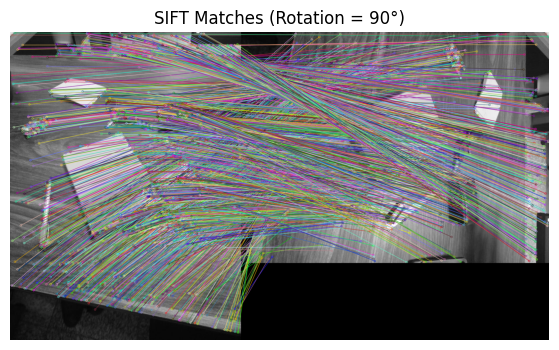

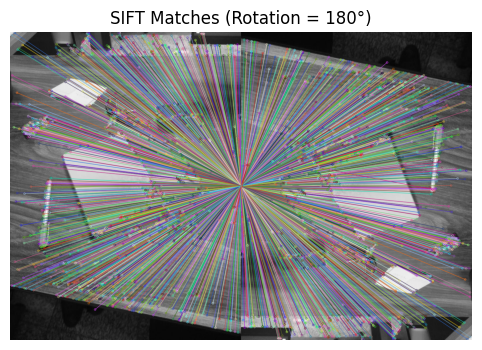

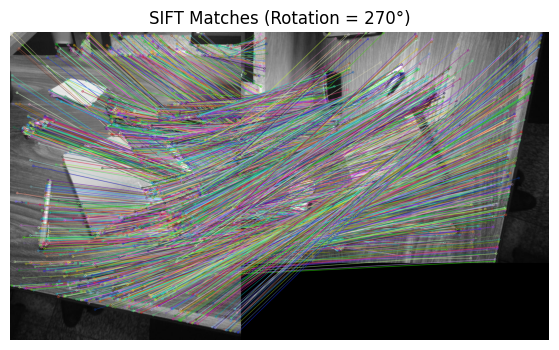

In [7]:
"""
Extract SIFT features and perform descriptor matching with Ratio Test.
"""

sift = cv2.SIFT_create()
bf = cv2.BFMatcher(cv2.NORM_L2)

# Extract features from reference image
kp_ref, des_ref = sift.detectAndCompute(img2, None)

baseline_match_counts = {}

for angle, img_rot in rotations.items():
    kp_rot, des_rot = sift.detectAndCompute(img_rot, None)

    matches = bf.knnMatch(des_ref, des_rot, k=2)

    good_matches = [
        m for m, n in matches if m.distance < 0.75 * n.distance
    ]

    baseline_match_counts[angle] = len(good_matches)

    matched_img = cv2.drawMatches(
        img2, kp_ref,
        img_rot, kp_rot,
        good_matches, None,
        flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS
    )

    plt.figure(figsize=(8, 4))
    plt.title(f"SIFT Matches (Rotation = {angle}°)")
    plt.imshow(matched_img, cmap="gray")
    plt.axis("off")
    plt.show()


### Discussion (Baseline)

Visual inspection shows that many keypoints are successfully matched
despite large image rotations. The presence of consistent correspondences
confirms the rotation invariance property of SIFT descriptors.

The baseline match counts serve as a reference for subsequent
quantitative analysis.


## Part 2: Rotation Angle Sensitivity Analysis

To analyze robustness more systematically, the image is rotated over
a wide range of angles. For each angle, SIFT matching performance
is evaluated using quantitative metrics.


In [8]:
"""
Perform SIFT matching over a wide range of rotation angles.
"""

angles = np.arange(0, 360, 30)

angle_results = {
    "angle": [],
    "keypoints": [],
    "good_matches": [],
    "match_ratio": []
}

for angle in angles:
    # Rotate image by arbitrary angle
    h, w = img2.shape
    center = (w // 2, h // 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    img_rot = cv2.warpAffine(img2, M, (w, h))

    kp_rot, des_rot = sift.detectAndCompute(img_rot, None)

    if des_rot is None:
        continue

    matches = bf.knnMatch(des_ref, des_rot, k=2)
    good = [m for m, n in matches if m.distance < 0.75 * n.distance]

    angle_results["angle"].append(angle)
    angle_results["keypoints"].append(len(kp_rot))
    angle_results["good_matches"].append(len(good))
    angle_results["match_ratio"].append(len(good) / max(len(kp_ref), 1))


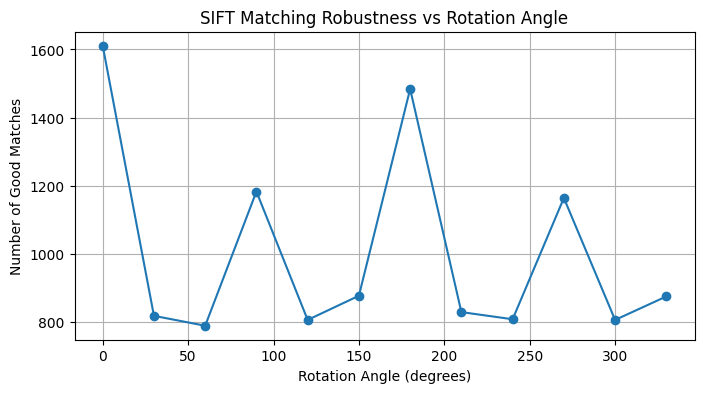

In [9]:
"""
Plot number of good matches versus rotation angle.
"""

plt.figure(figsize=(8, 4))
plt.plot(angle_results["angle"], angle_results["good_matches"], marker="o")
plt.xlabel("Rotation Angle (degrees)")
plt.ylabel("Number of Good Matches")
plt.title("SIFT Matching Robustness vs Rotation Angle")
plt.grid(True)
plt.show()


### Discussion

The number of successful matches remains relatively stable across
most rotation angles, with minor fluctuations caused by interpolation
effects during image rotation.

This confirms that SIFT descriptors preserve discriminative power
under significant rotational transformations.


## Part 3: Ratio Test Threshold Sensitivity

The Ratio Test threshold directly affects match quantity and quality.
This section evaluates how varying the threshold influences matching
results.


In [10]:
"""
Evaluate matching performance for different Ratio Test thresholds.
"""

ratio_values = np.arange(0.6, 0.9, 0.05)
ratio_results = []

kp_rot, des_rot = sift.detectAndCompute(rotations[90], None)
matches = bf.knnMatch(des_ref, des_rot, k=2)

for ratio in ratio_values:
    good = [m for m, n in matches if m.distance < ratio * n.distance]
    mean_dist = np.mean([m.distance for m in good]) if good else 0

    ratio_results.append((ratio, len(good), mean_dist))


"""
Plot Ratio Threshold vs Number of Matches.
"""

ratios, counts, distances = zip(*ratio_results)

plt.figure(figsize=(8, 4))
plt.plot(ratios, counts, marker="o")
plt.xlabel("Ratio Threshold")
plt.ylabel("Number of Good Matches")
plt.title("Effect of Ratio Test Threshold")
plt.grid(True)
plt.show()


### Discussion

Increasing the ratio threshold results in a larger number of matches,
but at the cost of higher descriptor distances, indicating weaker
correspondences.

This highlights the trade-off between match quantity and reliability
and justifies the commonly used threshold of 0.75.


## Part 4: Descriptor Distance Distribution

Analyzing the distribution of descriptor distances provides insight
into the overall quality of feature matching.


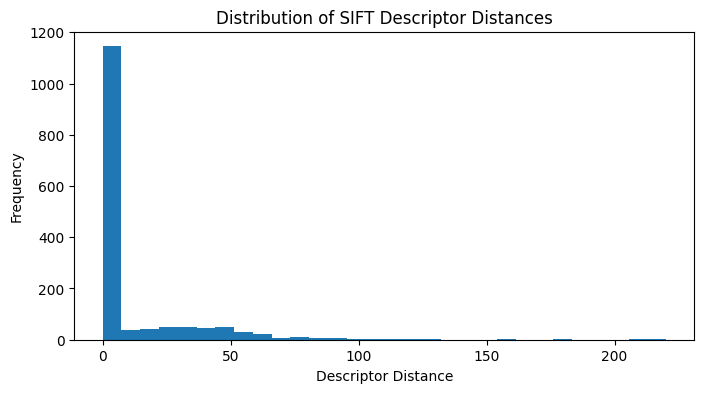

In [11]:
"""
Plot histogram of descriptor distances for good matches.
"""

distances = [m.distance for m, n in matches if m.distance < 0.75 * n.distance]

plt.figure(figsize=(8, 4))
plt.hist(distances, bins=30)
plt.xlabel("Descriptor Distance")
plt.ylabel("Frequency")
plt.title("Distribution of SIFT Descriptor Distances")
plt.show()


### Discussion

A concentrated distribution at lower distances indicates strong
feature correspondence. Wider distributions suggest increased ambiguity
in matching.


## Part 5: Geometric Consistency via Homography

Descriptor similarity alone does not guarantee geometric validity.
This section evaluates geometric consistency using homography estimation
with RANSAC.


In [12]:
"""
Estimate homography and compute inlier ratio.
"""

src_pts = np.float32([kp_ref[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
dst_pts = np.float32([kp_rot[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)

H, mask = cv2.findHomography(src_pts, dst_pts, cv2.RANSAC, 5.0)

inliers = np.sum(mask) if mask is not None else 0
inlier_ratio = inliers / max(len(good), 1)

print(f"Inlier Ratio: {inlier_ratio:.2f}")


Inlier Ratio: 0.99


### Final Discussion

Geometric verification confirms that a substantial portion of descriptor
matches are not only visually consistent but also geometrically valid.

This strengthens the conclusion that SIFT provides robust feature
matching under image rotation.


## Conclusion

This notebook extended a basic SIFT matching exercise into a systematic
experimental study. By sweeping rotation angles and matching parameters,
and by visualizing and quantifying results, the robustness of SIFT under
rotation was thoroughly evaluated.

Such analysis bridges the gap between algorithm implementation and
practical performance evaluation in computer vision.
